In [7]:
import sys
from pathlib import Path
base_path = Path.cwd().resolve().parent
sys.path.insert(0, str(base_path))
from config import ROOT_DIR

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [8]:
# 군집화된 데이터 불러오기
df = pd.read_csv(ROOT_DIR / 'data/KMeans_clusters.csv')

In [ ]:

# PCA로 2차원 축소
features = ['PurchaseCount', 'TotalSpent', 'AvgUnitPrice', 'UniqueItems']

pca = PCA(n_components=2)
components = pca.fit_transform(df[features])

df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

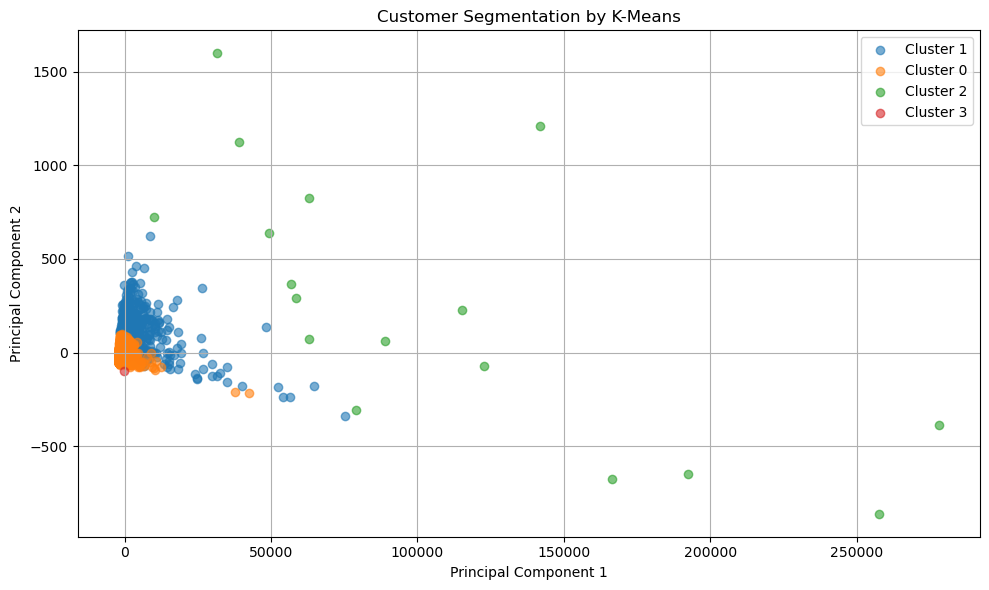

In [10]:
# 시각화
plt.figure(figsize=(10, 6))
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title('Customer Segmentation by K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()